# API Model Evaluation — Test Set (All Strategies)

Runs all 4 strategies (single-prompt, multi-hop, hybrid, hybrid-RAG) on:
- `gpt-3.5-turbo` — OpenAI

## Section 0 — Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/pipeline

/content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/pipeline


In [3]:
!pip install -q openai google-generativeai tqdm scikit-learn seaborn matplotlib pandas

## Section 1 — API Keys & Model Selection

In [ ]:
OPENAI_API_KEY = 'sk-...'       # OpenAI key

OPENAI_MODEL = 'gpt-3.5-turbo'

## Section 2 — Load Data & Modules

In [14]:
import pandas as pd
from src.config import (
    TEST_PATH, LABEL_COL, TEXT_COL, TICKER_COL,
    IN_CONTEXT_COL, EX_CONTEXT_COLS,
)

df_test = pd.read_csv(TEST_PATH)

# Sample 20 from each label
df_test = (
    df_test
    .groupby(LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(n=20, random_state=42))
)

print(f'Test set: {len(df_test):,} rows')
print(df_test[LABEL_COL].value_counts())
df_test.head(2)

Test set: 60 rows
true_sentiment
Negative    20
Neutral     20
Positive    20
Name: count, dtype: int64


/tmp/ipython-input-236/3484689627.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=20, random_state=42))


,published_at,ticker,true_sentiment,title,author,url,source,text,finbert_sentiment,finbert_sent_score,external_context_1,external_context_2,external_context_3
324,2023-04-03 18:53:00,USDJPY,Negative,USDJPY Price Analysis Retraces after failing t...,Christian Borjon Valencia,https://www.fxstreet.com/news/usd-jpy-price-an...,FX Street,USD/JPYretraces from two-week highs at around ...,Neutral,-0.39,"Gold, Silver, Platinum – Gold Moves Closer To ...",PRECIOUS-Gold prices ease as US dollar regains...,Dollar Gains on Inflationary Concerns\n\nDolla...
21,2023-02-17 14:11:00,EURUSD,Negative,EURUSD Price Analysis Further weakness could r...,Pablo Piovano,https://www.fxstreet.com/news/eur-usd-price-an...,FX Street,EUR/USDdrops to multi-week lows in the 1.0610 ...,Neutral,-0.04,Fed Fears Permeate Data-Filled Week on Wall St...,Fed Fears Permeate Data-Filled Week on Wall St...,Pre-Markets In The Red on Last Day of The Week...


In [15]:
import importlib
import src.prompts, src.inference, src.pipelines
importlib.reload(src.prompts)
importlib.reload(src.inference)
importlib.reload(src.pipelines)

import time
from tqdm import tqdm
from openai import RateLimitError, APIError, APITimeoutError
import src.inference as inference
from src.pipelines import single_prompt_pipeline, multihop_pipeline, hybrid_rag_pipeline
from src.evaluation import evaluate

print('Modules loaded.')

Modules loaded.


## Section 3 — Shared Helpers

In [16]:
def _safe_openai_call(fn, *args, **kwargs):
    for attempt in range(5):
        try:
            return fn(*args, **kwargs)
        except RateLimitError:
            wait = 2 ** attempt
            print(f'Rate limit, retrying in {wait}s... (attempt {attempt+1}/5)')
            time.sleep(wait)
        except (APIError, APITimeoutError) as e:
            wait = 2 ** attempt
            print(f'API error: {e}, retrying in {wait}s...')
            time.sleep(wait)
    return {'final': 'Neutral', 'hop1': None, 'hop2_bc': None, 'hop3_qc': None, 'mode': 'indirect'}


def _safe_gemini_call(fn, *args, **kwargs):
    for attempt in range(5):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            wait = 2 ** attempt
            print(f'Gemini error: {e}, retrying in {wait}s...')
            time.sleep(wait)
    return {'final': 'Neutral', 'hop1': None, 'hop2_bc': None, 'hop3_qc': None, 'mode': 'indirect'}


def run_all_strategies(df, model_tag, file_prefix, safe_call_fn, sleep_sec=1.5):
    """Run all 4 strategies and save CSVs."""
    records_sp, records_mh, records_hy, records_rag = [], [], [], []

    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=model_tag)):
        title  = row[TEXT_COL]
        ticker = row[TICKER_COL]
        label  = row[LABEL_COL]
        in_ctx = row.get(IN_CONTEXT_COL, '')
        ex1, ex2, ex3 = [row.get(c, '') for c in EX_CONTEXT_COLS]

        base_row = {'title': title, 'ticker': ticker, 'true_sentiment': label}

        out_sp  = safe_call_fn(single_prompt_pipeline, title, ticker)
        out_mh  = safe_call_fn(multihop_pipeline, title, ticker)
        out_hy  = safe_call_fn(hybrid_rag_pipeline, title, ticker)
        out_rag = safe_call_fn(hybrid_rag_pipeline, title, ticker, in_ctx, ex1, ex2, ex3)

        records_sp.append({**base_row, 'final_prediction': out_sp['final']})
        records_mh.append({**base_row,
            'hop1_fx_insight': out_mh['hop1'], 'hop2_bc_sentiment': out_mh['hop2_bc'],
            'hop3_qc_sentiment': out_mh['hop3_qc'], 'final_prediction': out_mh['final'],
        })
        records_hy.append({**base_row,
            'mode': out_hy['mode'], 'hop1_fx_insight': out_hy['hop1'],
            'hop2_bc_sentiment': out_hy['hop2_bc'], 'hop3_qc_sentiment': out_hy['hop3_qc'],
            'final_prediction': out_hy['final'],
        })
        records_rag.append({**base_row,
            'mode': out_rag['mode'], 'hop1_fx_insight': out_rag['hop1'],
            'hop2_bc_sentiment': out_rag['hop2_bc'], 'hop3_qc_sentiment': out_rag['hop3_qc'],
            'final_prediction': out_rag['final'],
        })

        # Checkpoint every 50 rows
        if i > 0 and i % 50 == 0:
            pd.DataFrame(records_sp).to_csv(f'data/finance/checkpoint_{file_prefix}_sp.csv', index=False)
            print(f'Checkpoint saved at row {i}')

        time.sleep(sleep_sec)

    results = {
        'single_prompt': pd.DataFrame(records_sp),
        'multihop':      pd.DataFrame(records_mh),
        'hybrid':        pd.DataFrame(records_hy),
        'hybrid_rag':    pd.DataFrame(records_rag),
    }

    for strategy, df_res in results.items():
        path = f'data/finance/result_test_{file_prefix}_{strategy}.csv'
        df_res.to_csv(path, index=False)
        evaluate(df_res, title=f'{model_tag} / {strategy} — Test')

    return results

## Section 4 — Run GPT-3.5-Turbo

[inference] Backend set to 'openai'  model=gpt-3.5-turbo


GPT-3.5-Turbo:  83%|████████▎ | 50/60 [05:23<00:59,  5.93s/it]

Checkpoint saved at row 50


GPT-3.5-Turbo: 100%|██████████| 60/60 [06:18<00:00,  6.30s/it]



──────────────────────────────────────────────────
  GPT-3.5-Turbo / single_prompt — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7833
  Macro F1  : 0.7715

              precision    recall  f1-score   support

    Positive     0.7037    0.9500    0.8085        20
     Neutral     0.7692    0.5000    0.6061        20
    Negative     0.9000    0.9000    0.9000        20

    accuracy                         0.7833        60
   macro avg     0.7910    0.7833    0.7715        60
weighted avg     0.7910    0.7833    0.7715        60



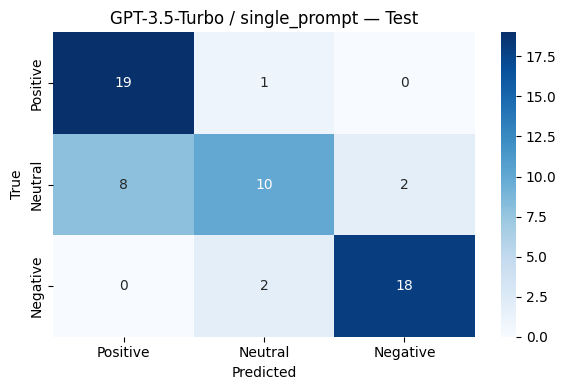


──────────────────────────────────────────────────
  GPT-3.5-Turbo / multihop — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7667
  Macro F1  : 0.7538

              precision    recall  f1-score   support

    Positive     0.8095    0.8500    0.8293        20
     Neutral     0.7692    0.5000    0.6061        20
    Negative     0.7308    0.9500    0.8261        20

    accuracy                         0.7667        60
   macro avg     0.7698    0.7667    0.7538        60
weighted avg     0.7698    0.7667    0.7538        60



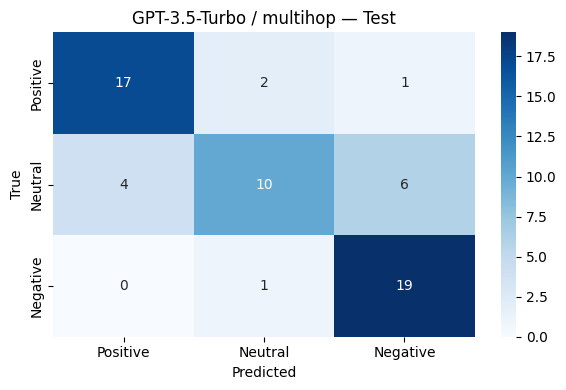


──────────────────────────────────────────────────
  GPT-3.5-Turbo / hybrid — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7833
  Macro F1  : 0.7814

              precision    recall  f1-score   support

    Positive     0.8421    0.8000    0.8205        20
     Neutral     0.6842    0.6500    0.6667        20
    Negative     0.8182    0.9000    0.8571        20

    accuracy                         0.7833        60
   macro avg     0.7815    0.7833    0.7814        60
weighted avg     0.7815    0.7833    0.7814        60



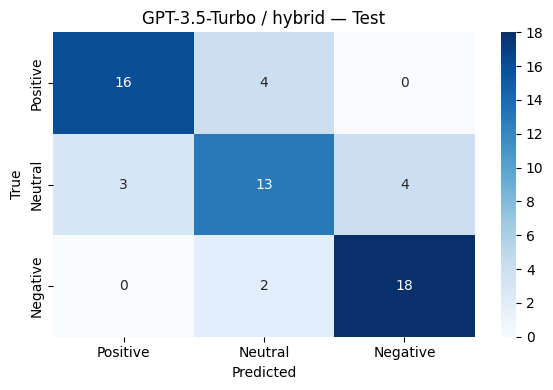


──────────────────────────────────────────────────
  GPT-3.5-Turbo / hybrid_rag — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7833
  Macro F1  : 0.7814

              precision    recall  f1-score   support

    Positive     0.8421    0.8000    0.8205        20
     Neutral     0.6842    0.6500    0.6667        20
    Negative     0.8182    0.9000    0.8571        20

    accuracy                         0.7833        60
   macro avg     0.7815    0.7833    0.7814        60
weighted avg     0.7815    0.7833    0.7814        60



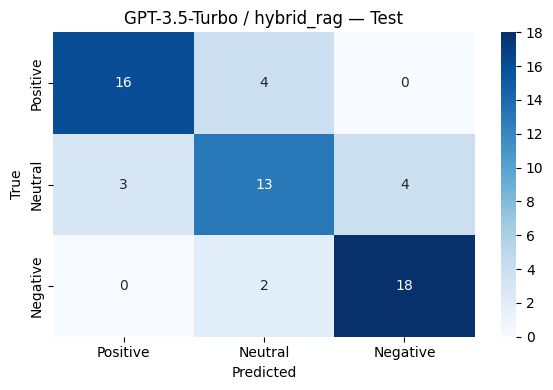

In [17]:
inference.set_backend('openai', model=OPENAI_MODEL, api_key=OPENAI_API_KEY)
results_gpt35 = run_all_strategies(
    df_test,
    model_tag='GPT-3.5-Turbo',
    file_prefix='gpt35',
    safe_call_fn=_safe_openai_call,
    sleep_sec=1.5,
)

## Section 6 — Cross-Model Comparison

In [18]:
from sklearn.metrics import accuracy_score, f1_score

flan_files = {
    'single_prompt': 'data/finance/result_test_singleprompt.csv',
    'multihop':      'data/finance/result_test_multihop.csv',
    'hybrid':        'data/finance/result_test_hybrid.csv',
    'hybrid_rag':    'data/finance/result_test_hybrid_RAG.csv',
}

gpt_files = {
    'single_prompt': 'data/finance/result_test_gpt35_single_prompt.csv',
    'multihop':      'data/finance/result_test_gpt35_multihop.csv',
    'hybrid':        'data/finance/result_test_gpt35_hybrid.csv',
    'hybrid_rag':    'data/finance/result_test_gpt35_hybrid_rag.csv',
}

def build_table(files, model_name):
    rows = []
    for strategy, path in files.items():
        try:
            df = pd.read_csv(path)
            acc = accuracy_score(df[LABEL_COL], df['final_prediction'])
            f1  = f1_score(df[LABEL_COL], df['final_prediction'], average='macro', zero_division=0)
            rows.append({
                'Model':    model_name,
                'Strategy': strategy,
                'Accuracy': round(acc, 4),
                'Macro F1': round(f1, 4),
            })
        except FileNotFoundError:
            print(f'Skipped (file not found): {path}')
    return pd.DataFrame(rows)

flan_summary = build_table(flan_files, 'FLAN-T5-XXL')
gpt_summary  = build_table(gpt_files,  'GPT-3.5-Turbo')

print('=== FLAN-T5-XXL — Test Set ===')
print(flan_summary.to_string(index=False))
print()
print('=== GPT-3.5-Turbo — Test Set ===')
print(gpt_summary.to_string(index=False))

# Save combined
combined = pd.concat([flan_summary, gpt_summary], ignore_index=True)
combined.to_csv('data/finance/comparison_all_models.csv', index=False)

=== FLAN-T5-XXL — Test Set ===
      Model      Strategy  Accuracy  Macro F1
FLAN-T5-XXL single_prompt    0.7100    0.6977
FLAN-T5-XXL      multihop    0.7641    0.7616
FLAN-T5-XXL        hybrid    0.7706    0.7686
FLAN-T5-XXL    hybrid_rag    0.7684    0.7669

=== GPT-3.5-Turbo — Test Set ===
        Model      Strategy  Accuracy  Macro F1
GPT-3.5-Turbo single_prompt    0.7833    0.7715
GPT-3.5-Turbo      multihop    0.7667    0.7538
GPT-3.5-Turbo        hybrid    0.7833    0.7814
GPT-3.5-Turbo    hybrid_rag    0.7833    0.7814
